## 1) F1 스코어(F1 Score)
* 정밀도와 재현율을 결합한 지표
* 정밀도와 재현율이 어느 한쪽으로 치우치지 않는 수치를 나타낼 때 상대적으로 높은 값을 가짐
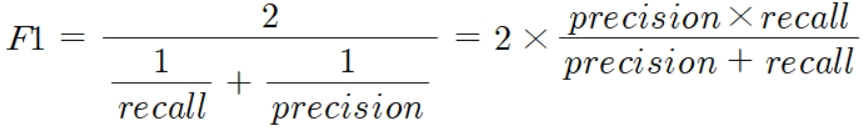
* 사이킷런에서 f1_score() API 제공

In [1]:
### 2.6. 참고

from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 속성 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [3]:
### 로지스틱 회귀 기반 타이타닉 생존자 모델 사용
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

titanic_df = pd.read_csv(r'./kaggle/titanic/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
x_titanic_df = titanic_df.drop('Survived', axis=1)
x_titanic_df = transform_features(x_titanic_df)

x_train, x_test, y_train, y_test = train_test_split(x_titanic_df, y_titanic_df, test_size=0.2, random_state=11)

lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)
pred = lr_clf.predict(x_test)

C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
### f1스코어 계산
from sklearn.metrics import f1_score
f1 = f1_score(y_test, pred)
print('F1 스코어 : {0:.4f}'.format(f1))

F1 스코어 : 0.7805


In [9]:
### 3.3 참고
from sklearn.preprocessing import Binarizer

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print("임곗값 : ", custom_threshold)
        get_clf_eval(y_test, custom_predict)

In [10]:
### 임곗값을 변화시키며 평가지표 구하기
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    print('오차행렬 : ')
    print(confusion)
    
    print('정확도 : {0:.4f} , 정밀도 : {1:.4f} , 재현율 : {2:.4f} , F1 : {3:.4f}'.format(accuracy, precision, recall, f1))

thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]
pred_proba = lr_clf.predict_proba(x_test)
get_eval_by_threshold(y_test, pred_proba[:, -1].reshape(-1, 1), thresholds)

임곗값 :  0.4
오차행렬 : 
[[99 19]
 [10 51]]
정확도 : 0.8380 , 정밀도 : 0.7286 , 재현율 : 0.8361 , F1 : 0.7786
임곗값 :  0.45
오차행렬 : 
[[103  15]
 [ 12  49]]
정확도 : 0.8492 , 정밀도 : 0.7656 , 재현율 : 0.8033 , F1 : 0.7840
임곗값 :  0.5
오차행렬 : 
[[104  14]
 [ 13  48]]
정확도 : 0.8492 , 정밀도 : 0.7742 , 재현율 : 0.7869 , F1 : 0.7805
임곗값 :  0.55
오차행렬 : 
[[109   9]
 [ 15  46]]
정확도 : 0.8659 , 정밀도 : 0.8364 , 재현율 : 0.7541 , F1 : 0.7931
임곗값 :  0.6
오차행렬 : 
[[112   6]
 [ 16  45]]
정확도 : 0.8771 , 정밀도 : 0.8824 , 재현율 : 0.7377 , F1 : 0.8036
